In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier



from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter



from sklearn.metrics import confusion_matrix 
from sklearn.metrics import  accuracy_score , recall_score , f1_score
from sklearn.metrics import classification_report





In [84]:
data = pd.read_csv(r'C:\Users\MicroTech\Desktop\archive\diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [85]:
data.head()
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [86]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [87]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [88]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [89]:
data.duplicated().sum()

np.int64(0)

In [90]:
data.shape

(768, 9)

In [91]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

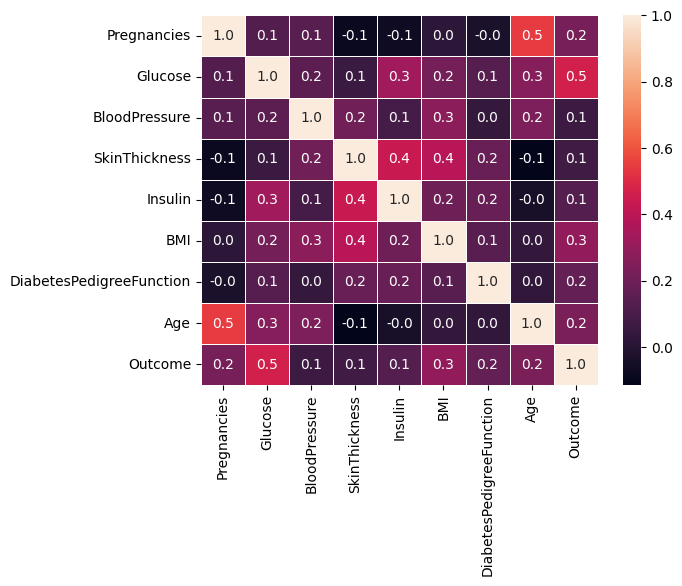

In [92]:
sns.heatmap(data.corr() ,annot=True ,fmt='0.1f' ,linewidths=.5 )

<Axes: xlabel='Outcome', ylabel='count'>

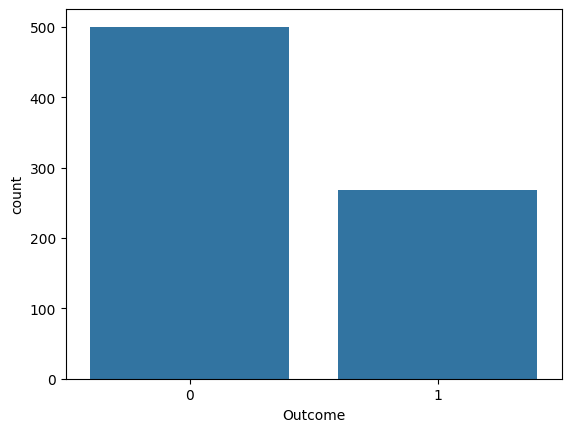

In [93]:
sns.countplot(x= 'Outcome', data=data)

In [94]:
MAX=data[data['Outcome']==0] 
MIN=data[data['Outcome']==1]
MAX.shape , MIN.shape
268/(500+268)

0.3489583333333333

<Axes: ylabel='Age'>

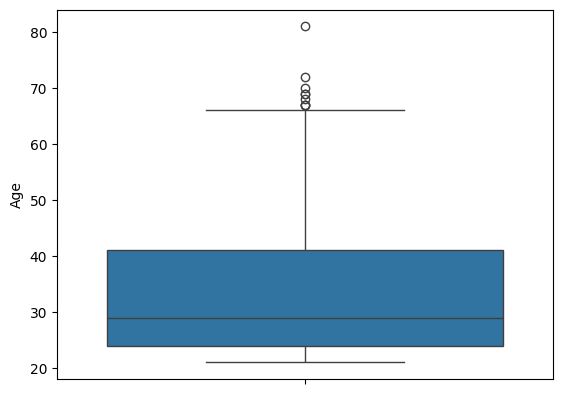

In [95]:
sns.boxplot(data.Age)

In [96]:
x = data.drop('Outcome' , axis=1)
y = data['Outcome']

In [97]:
rm = RandomOverSampler(random_state=41)
x_res, y_res = rm.fit_resample(x,y)


In [98]:
print('old dataset shape %s' % Counter(y))
print('new dataset shape %s' % Counter(y_res))


old dataset shape Counter({0: 500, 1: 268})
new dataset shape Counter({1: 500, 0: 500})


In [99]:
x_train , x_test , y_train , y_test = train_test_split(x_res,y_res,test_size=0.2 , random_state=41)

In [100]:
model1 = LogisticRegression()
model2 =SVC()
model3 = RandomForestClassifier(		n_estimators=100, class_weight='balanced')
model4 = GradientBoostingClassifier(n_estimators=1000)

In [101]:
colums = ['LogisticRegression' , 'svc' , 'RandomForestClassifier' , 'GradientBoostingClassifier']
result1=[]
result2=[]
result3 =[]

c:\Users\MicroTech\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()
accuracy is : 0.74 recall is : 0.78125 f1 is : 0.7425742574257426


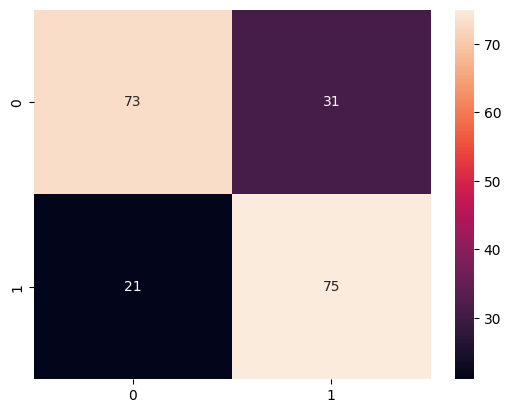

In [102]:
def cal(model):
    model.fit(x_train ,y_train)
    pre =model.predict(x_test)
    accuracy=accuracy_score(pre ,y_test)
    recall=recall_score(pre, y_test)
    f1=f1_score(pre ,y_test)
    result1.append(accuracy)
    result2.append(recall)
    result3.append(f1)
    
    sns.heatmap(confusion_matrix(pre, y_test), annot=True)
    print(model)
    print('accuracy is :', accuracy , 'recall is :' , recall , 'f1 is :',f1)
cal(model1)

SVC()
accuracy is : 0.69 recall is : 0.7291666666666666 f1 is : 0.693069306930693


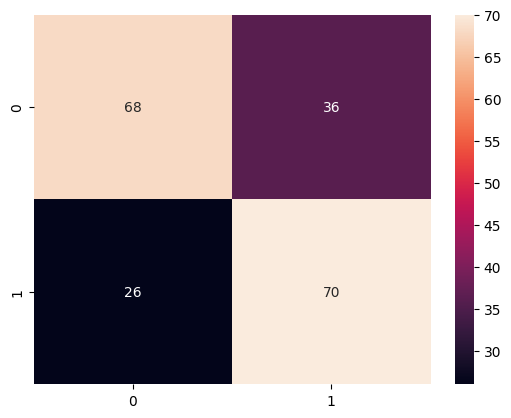

In [103]:
cal(model2)

RandomForestClassifier(class_weight='balanced')
accuracy is : 0.865 recall is : 0.8495575221238938 f1 is : 0.8767123287671232


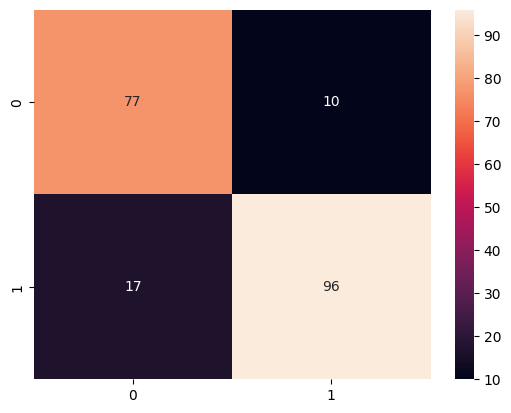

In [104]:
cal(model3)

GradientBoostingClassifier(n_estimators=1000)
accuracy is : 0.855 recall is : 0.8468468468468469 f1 is : 0.8663594470046083


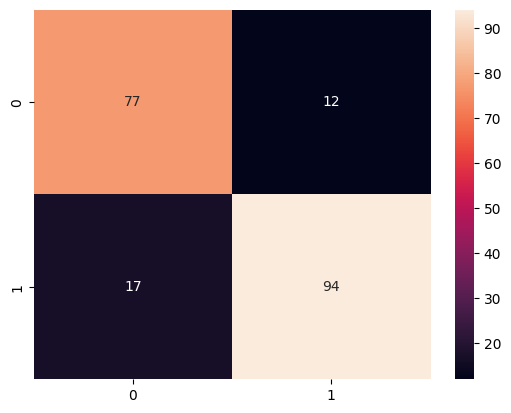

In [105]:
cal(model4)

In [106]:
result1


[0.74, 0.69, 0.865, 0.855]

In [107]:
result2

[0.78125, 0.7291666666666666, 0.8495575221238938, 0.8468468468468469]

In [108]:
result3

[0.7425742574257426, 0.693069306930693, 0.8767123287671232, 0.8663594470046083]

In [109]:
final_result=pd.DataFrame({'Algorithm' : colums , 'Accuracy' : result1 , 'recall' : result2 , 'f1_score': result3})
final_result

,Algorithm,Accuracy,recall,f1_score
0,LogisticRegression,0.740,0.781250,0.742574
1,svc,0.690,0.729167,0.693069
2,RandomForestClassifier,0.865,0.849558,0.876712
3,GradientBoostingClassifier,0.855,0.846847,0.866359


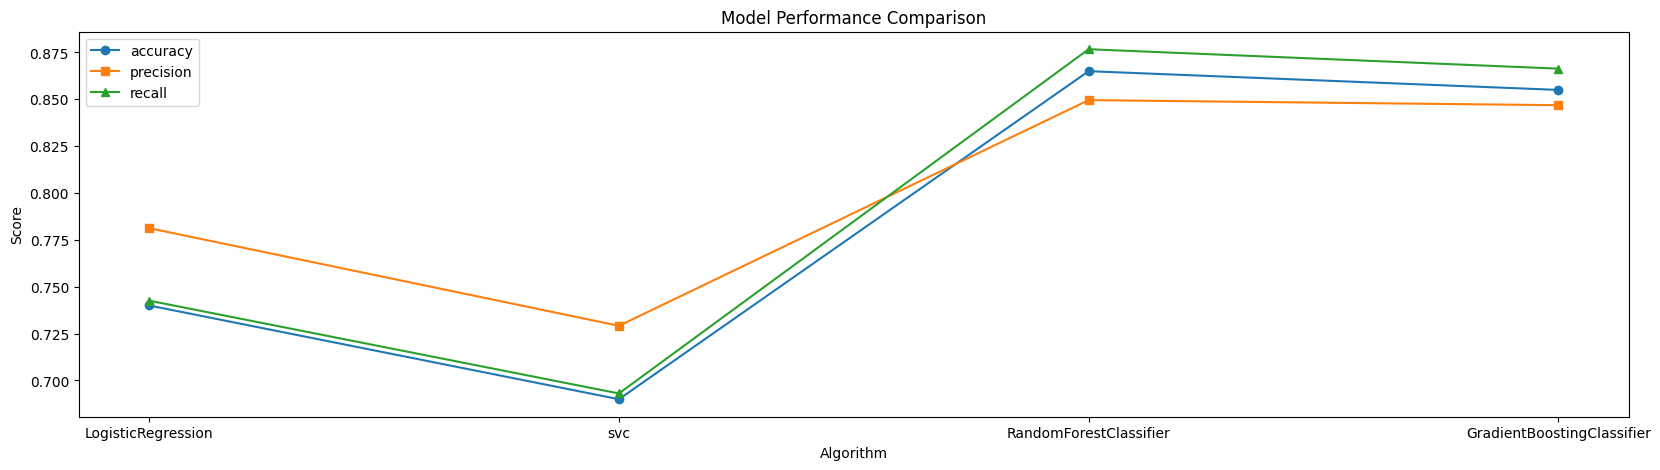

In [110]:
fig,ax=plt.subplots(figsize=(20,5))
plt.plot(final_result.Algorithm,result1,marker='o',label='accuracy')
plt.plot(final_result.Algorithm,result2,marker='s',label='precision')
plt.plot(final_result.Algorithm,result3,marker='^',label='recall')
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

In [112]:
import pickle